# Passive compliance — piano

## Piano playing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.join('../../'))
sys.path.insert(0, 'HelperPianoMIDI')
from plot_config import draw_radar
from piano_config import K_SWEEP, K_STIFF, K_SOFT, PRESS_DEPTH, PRESS_SPEED

OUTPUT_DIR_PLAY = os.path.join('outputs', 'piano_playing_hand')
os.makedirs(OUTPUT_DIR_PLAY, exist_ok=True)

K_SWEEP      = [float(k) for k in K_SWEEP]
K_STIFF      = float(K_STIFF)
K_SOFT       = float(K_SOFT)
PRESS_PERIOD = 2 * PRESS_DEPTH / PRESS_SPEED   # [s] full key-press cycle

IDX = slice(7, 9)
RNG = slice(11, 13)
N_GRID = 200

def load_cycles(condition, k_label):
    folder = os.path.join(OUTPUT_DIR_PLAY, condition, f'K_{k_label}')
    if not os.path.isdir(folder):
        return []
    files = sorted(f for f in os.listdir(folder) if f.endswith('.csv'))
    return [pd.read_csv(os.path.join(folder, f)) for f in files]

def tau_norm(df, sl):
    cols = [f'tau_{i}' for i in range(sl.start, sl.stop)]
    return np.linalg.norm(df[cols].to_numpy(), axis=1)

def interp_cycle(arr, n=N_GRID):
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, arr)

### Uniform condition — torque norm vs stiffness

/tmp/ipykernel_26222/3394692384.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small')


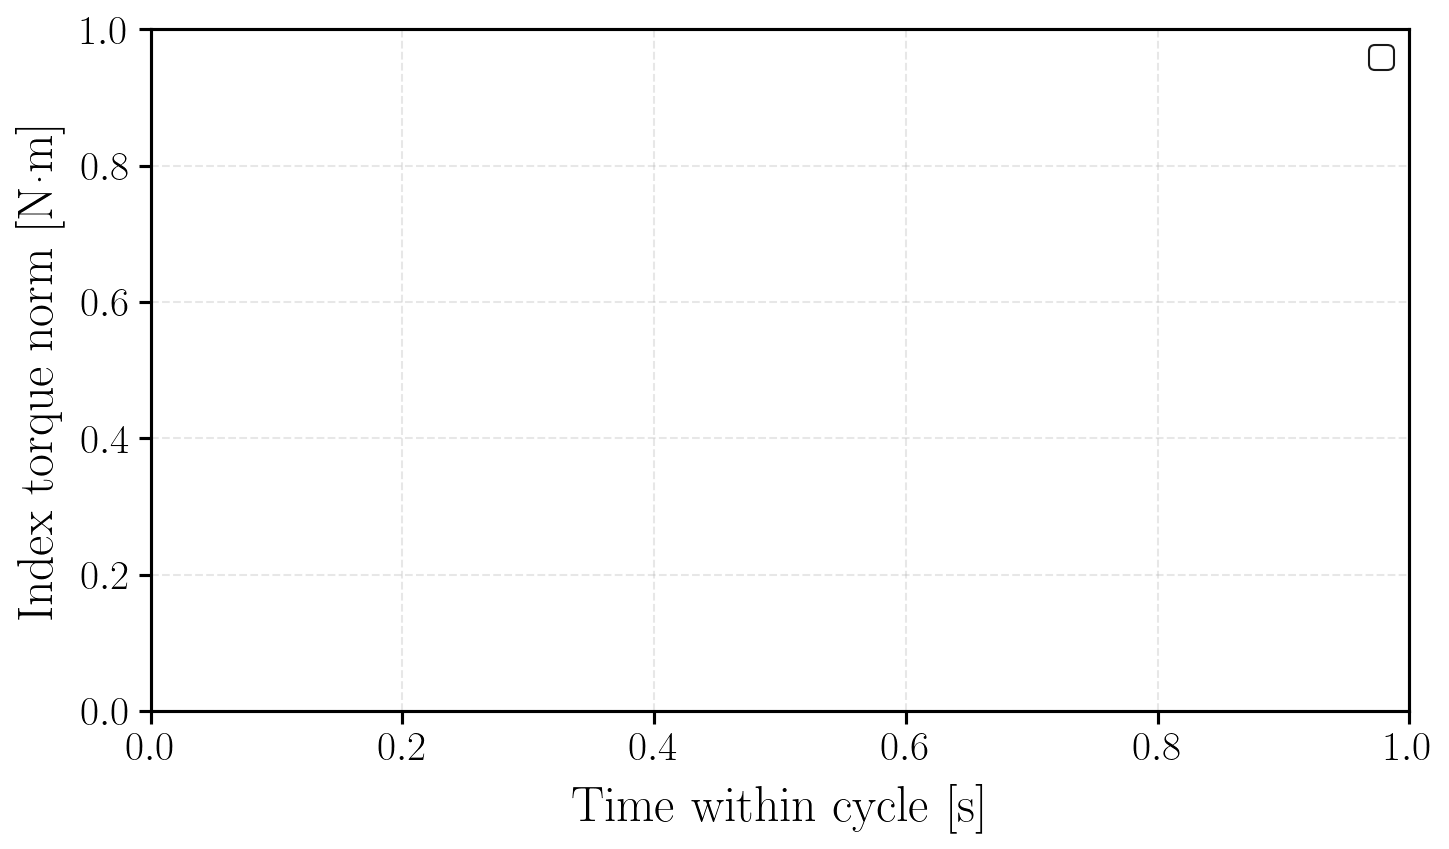

In [2]:
fig, ax = plt.subplots()
T = np.linspace(0, PRESS_PERIOD, N_GRID)
colors = ['#56B4E9', '#E69F00', '#000000']

for color, K in zip(colors, K_SWEEP):
    cycles = load_cycles('uniform', f'{K:.0f}')
    if not cycles:
        continue
    traces = np.stack([interp_cycle(tau_norm(df, IDX)) for df in cycles])
    mu, sigma = traces.mean(0), traces.std(0)
    ax.plot(T, mu, color=color, label=f'$k_{{tip}}={K:.0f}$ N/m')
    ax.fill_between(T, mu - sigma, mu + sigma, color=color, alpha=0.15)

ax.set_xlabel('Time within cycle [s]')
ax.set_ylabel('Index torque norm [N·m]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'uniform_torque_vs_stiffness.pdf'), bbox_inches='tight')
plt.show()

### Heterogeneous condition — stiff index vs soft ring

/tmp/ipykernel_26222/207776042.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small')


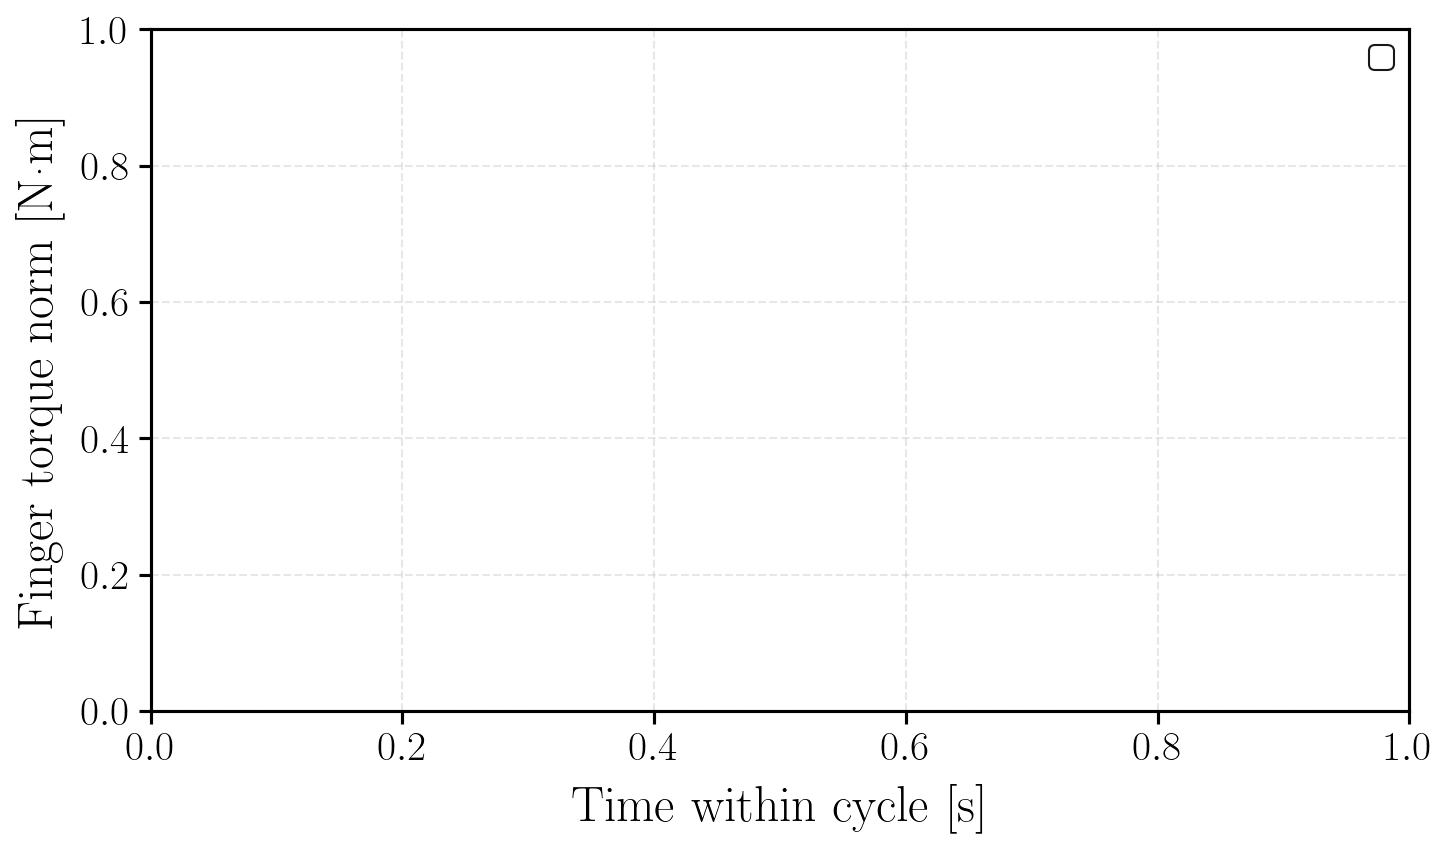

In [3]:
fig, ax = plt.subplots()
T = np.linspace(0, PRESS_PERIOD, N_GRID)
k_lbl = f'stiff{K_STIFF:.0f}_soft{K_SOFT:.0f}'
cycles = load_cycles('heterogeneous', k_lbl)

for color, sl, label in [
    ('#0072B2', IDX, f'Index  ($k={K_STIFF:.0f}$ N/m)'),
    ('#D55E00', RNG, f'Ring   ($k={K_SOFT:.0f}$ N/m)'),
]:
    if not cycles:
        continue
    traces = np.stack([interp_cycle(tau_norm(df, sl)) for df in cycles])
    mu, sigma = traces.mean(0), traces.std(0)
    ax.plot(T, mu, color=color, label=label)
    ax.fill_between(T, mu - sigma, mu + sigma, color=color, alpha=0.15)

ax.set_xlabel('Time within cycle [s]')
ax.set_ylabel('Finger torque norm [N·m]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'heterogeneous_index_vs_ring.pdf'), bbox_inches='tight')
plt.show()

## Glissando

In [4]:
OUTPUT_DIR_GLIS = os.path.join('outputs', 'piano_glissando')
os.makedirs(OUTPUT_DIR_GLIS, exist_ok=True)

from piano_config import N_RUNS, GLISSANDO_DISTANCE, GLISSANDO_SPEED

N_RUNS             = int(N_RUNS)
GLISSANDO_DISTANCE = float(GLISSANDO_DISTANCE)
GLISSANDO_SPEED    = float(GLISSANDO_SPEED)
GLISSANDO_DURATION = GLISSANDO_DISTANCE / GLISSANDO_SPEED

IDX_MCP, MID_MCP = 7, 9

def load_slide(run):
    path = os.path.join(OUTPUT_DIR_GLIS, f'run_{run}.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    return df[df['phase'] == 'slide_forward'].reset_index(drop=True)

def interp_trace(arr, n=N_GRID):
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, arr)

runs = [load_slide(r) for r in range(1, N_RUNS + 1)]
runs = [df for df in runs if df is not None and len(df) > 5]
T_glis = np.linspace(0, GLISSANDO_DURATION, N_GRID)

### MCP joint angles during the slide

/tmp/ipykernel_26222/2156034253.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


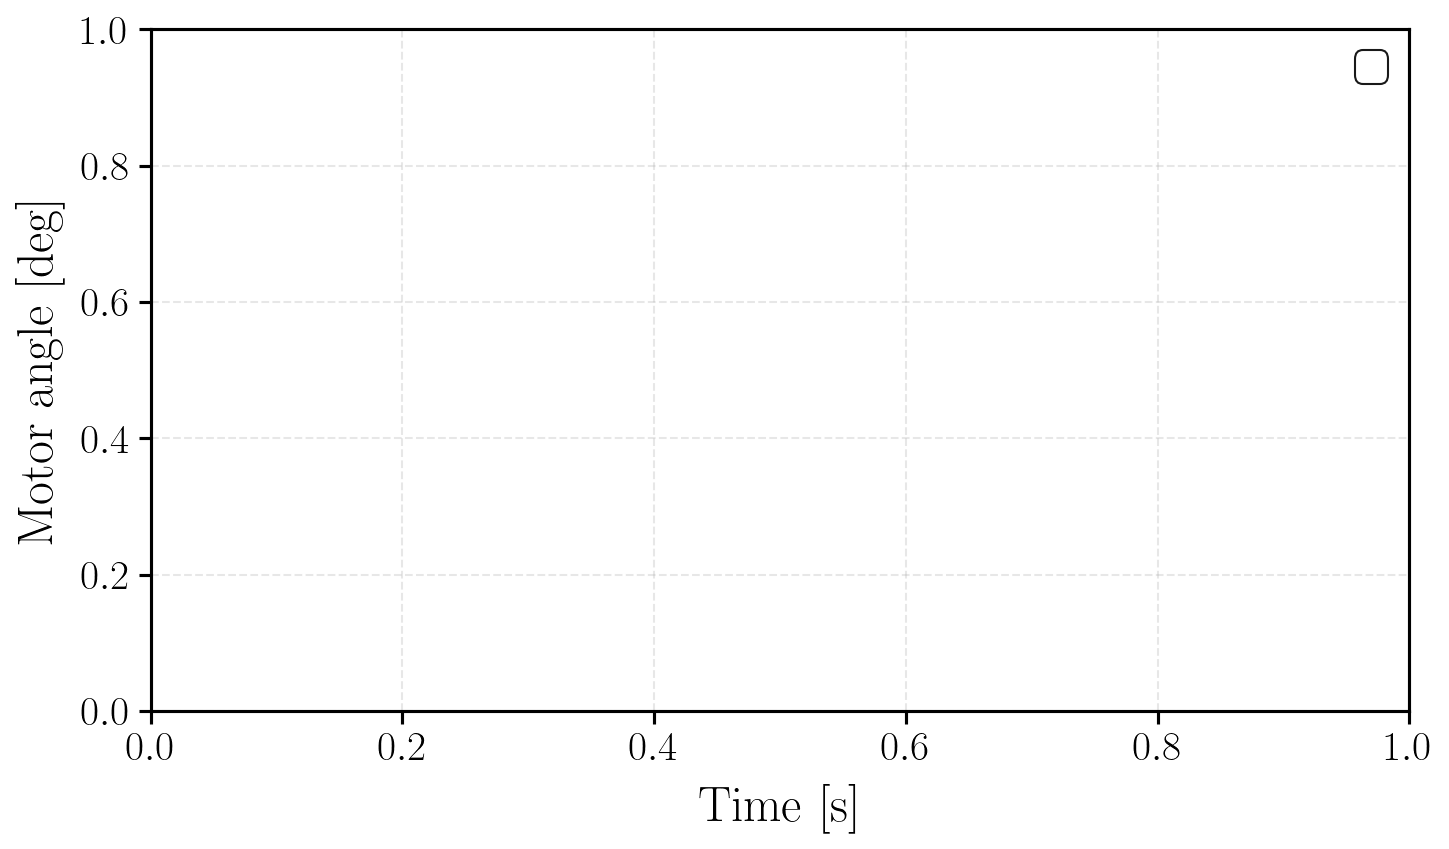

In [5]:
fig, ax = plt.subplots()

for color, col, label in [
    ('#0072B2', f'q_{IDX_MCP}', 'Index MCP'),
    ('#D55E00', f'q_{MID_MCP}', 'Middle MCP'),
]:
    if not runs:
        continue
    traces = np.stack([interp_trace(np.rad2deg(df[col].to_numpy())) for df in runs])
    mu, sigma = traces.mean(0), traces.std(0)
    ax.plot(T_glis, mu, color=color, label=label)
    ax.fill_between(T_glis, mu - sigma, mu + sigma, color=color, alpha=0.15)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Motor angle [deg]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR_GLIS, 'glissando_angles.pdf'), bbox_inches='tight')
plt.show()

### MCP torques during the slide

/tmp/ipykernel_26222/3680383822.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


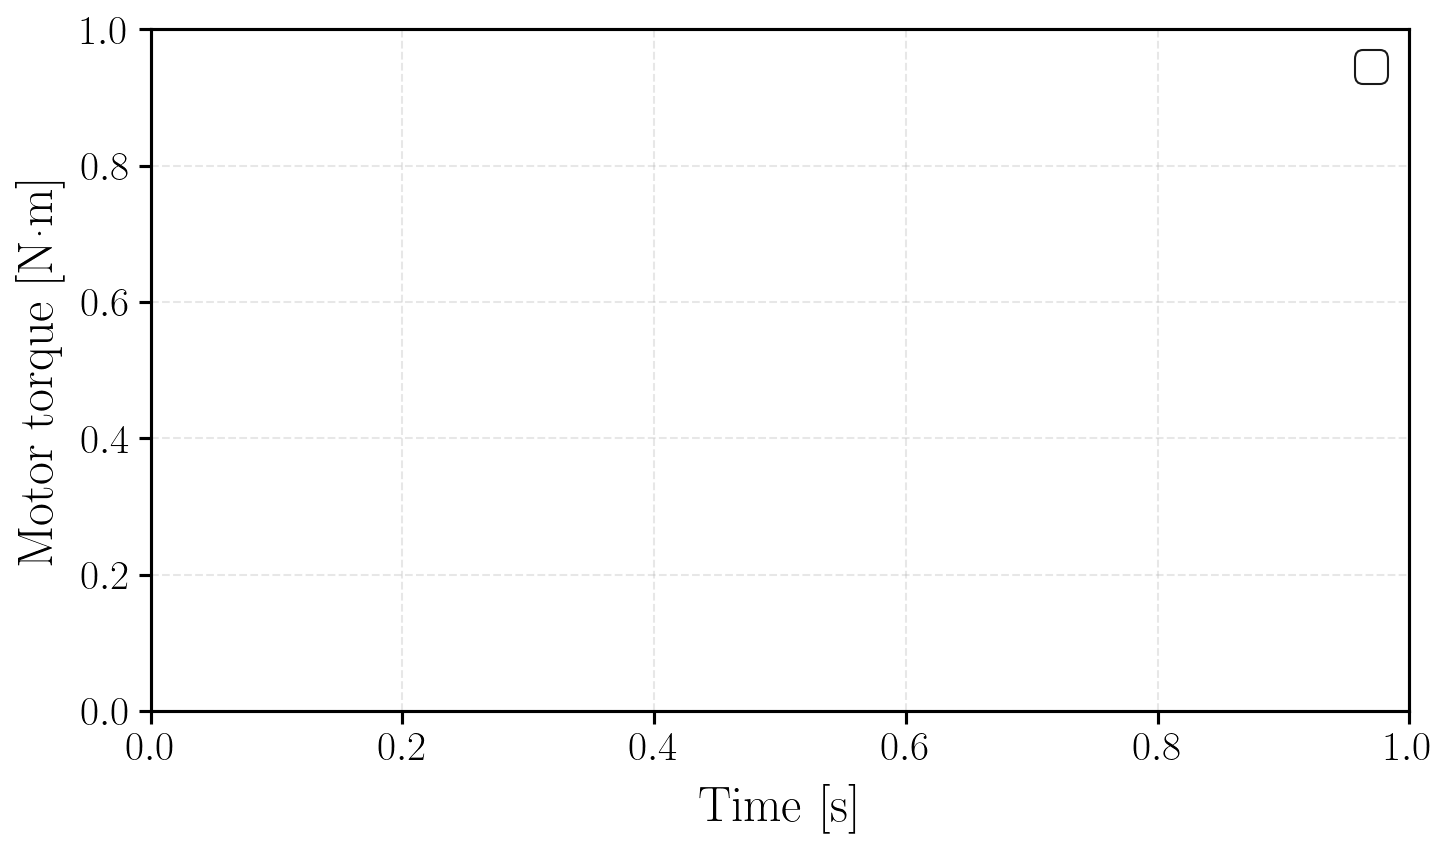

In [6]:
fig, ax = plt.subplots()

for color, col, label in [
    ('#0072B2', f'tau_{IDX_MCP}', 'Index MCP'),
    ('#D55E00', f'tau_{MID_MCP}', 'Middle MCP'),
]:
    if not runs:
        continue
    traces = np.stack([interp_trace(df[col].to_numpy()) for df in runs])
    mu, sigma = traces.mean(0), traces.std(0)
    ax.plot(T_glis, mu, color=color, label=label)
    ax.fill_between(T_glis, mu - sigma, mu + sigma, color=color, alpha=0.15)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Motor torque [N·m]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR_GLIS, 'glissando_torques.pdf'), bbox_inches='tight')
plt.show()